In [27]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [28]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import json,requests
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,AIMessage
from pydantic import BaseModel,Field

class WeatherLoc(BaseModel):
    """the location to get the weather"""
    location:str=Field(description="the location to get the weather")

class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query:str=Field(description="the query to fetch real time infor")
    
@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url="https://api.open-meteo.com/v1/forecast?latitude=52.52&longitude=13.41&t_weather=true"
    response=requests.get(url)
    result=json.loads(response.text)
    return result



@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)



In [29]:
get_weather.invoke("beijing")

'{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 800, "main": "Clear", "description": "\\u6674", "icon": "01d"}], "base": "stations", "main": {"temp": 33.2, "feels_like": 31.84, "temp_min": 33.2, "temp_max": 33.2, "pressure": 1002, "humidity": 27, "sea_level": 1002, "grnd_level": 997}, "visibility": 10000, "wind": {"speed": 5.82, "deg": 198, "gust": 8.36}, "clouds": {"all": 0}, "dt": 1782116512, "sys": {"country": "CN", "sunrise": 1782074768, "sunset": 1782128784}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}'

In [30]:
fetch_real_time_info.invoke("小米汽车")

--------------


{'latitude': 52.52,
 'longitude': 13.419998,
 'generationtime_ms': 0.001430511474609375,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 38.0}

In [31]:
tools=[get_weather,fetch_real_time_info]
tool_node=ToolNode(tools)

In [32]:
llm=llm.bind_tools(tools)

In [33]:
def should_contine(state):
    messages=state["messages"]
    last_message=messages[-1]
    
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [34]:
def call_model(state):
    messages=state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [35]:
workflow=StateGraph(MessagesState)

workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)

workflow.add_edge(START,"agent")

workflow.add_conditional_edges(
    "agent",
    should_contine,
    {
        "continue":"action",
        "end":END
    }
)

workflow.add_edge("action","agent")

In [36]:
memory=MemorySaver()

graph=workflow.compile(checkpointer=memory,interrupt_before=["action"])

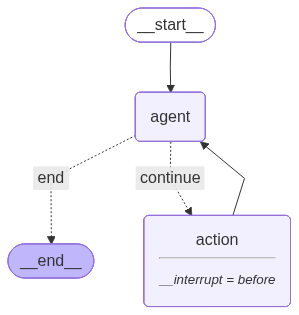

In [37]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
config={"configurable":{"thread_id":"4"}}

for chunk in graph.stream({"messages":"请帮我查一下北京的天气"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

请帮我查一下北京的天气
================================== Ai Message ==================================

我来帮你查一下北京的天气。
Tool Calls:
  get_weather (call_00_v18OTRESaXGozImd0p0W2794)
 Call ID: call_00_v18OTRESaXGozImd0p0W2794
  Args:
    location: Beijing


In [39]:
for chunk in graph.stream(None,config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

我来帮你查一下北京的天气。
Tool Calls:
  get_weather (call_00_v18OTRESaXGozImd0p0W2794)
 Call ID: call_00_v18OTRESaXGozImd0p0W2794
  Args:
    location: Beijing
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 800, "main": "Clear", "description": "\u6674", "icon": "01d"}], "base": "stations", "main": {"temp": 33.2, "feels_like": 31.84, "temp_min": 33.2, "temp_max": 33.2, "pressure": 1002, "humidity": 27, "sea_level": 1002, "grnd_level": 997}, "visibility": 10000, "wind": {"speed": 5.82, "deg": 198, "gust": 8.36}, "clouds": {"all": 0}, "dt": 1782116512, "sys": {"country": "CN", "sunrise": 1782074768, "sunset": 1782128784}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}
================================== Ai Message ==================================

以下是北京当前的天气情况：

🌤 **天气状况**：晴天
🌡 **温度**：3

In [40]:
config={"configurable":{"thread_id":"5"}}

for chunk in graph.stream({"messages":"小米汽车"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

小米汽车
================================== Ai Message ==================================

我来帮你查询关于小米汽车的最新信息。
Tool Calls:
  fetch_real_time_info (call_00_TBpRKcEtDjt3WZEb9p8v6568)
 Call ID: call_00_TBpRKcEtDjt3WZEb9p8v6568
  Args:
    query: 小米汽车 最新消息 2025


In [41]:
for chunk in graph.stream(None,config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

我来帮你查询关于小米汽车的最新信息。
Tool Calls:
  fetch_real_time_info (call_00_TBpRKcEtDjt3WZEb9p8v6568)
 Call ID: call_00_TBpRKcEtDjt3WZEb9p8v6568
  Args:
    query: 小米汽车 最新消息 2025
--------------
================================= Tool Message =================================
Name: fetch_real_time_info

{"latitude": 52.52, "longitude": 13.419998, "generationtime_ms": 0.0022649765014648438, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 38.0}
================================== Ai Message ==================================
Tool Calls:
  fetch_real_time_info (call_00_gR1yFQSLsMGDnH7f9LJ68272)
 Call ID: call_00_gR1yFQSLsMGDnH7f9LJ68272
  Args:
    query: 小米汽车 SU7 最新动态 2025
